In [2]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as matplot
import re
import logging
import os
import warnings
import altair as alt
warnings.filterwarnings("ignore")


In [3]:
#reading excel with multiple sheets and selecting a specific sheet
gls = pd.ExcelFile('Twelve Year Guardian League Table (1).xlsx')
sld_df  = pd.read_excel(gls,'Subject Level Data')
isd_df = pd.read_excel(gls,'Institution Level Data')

In [10]:
sld_df[(sld_df['Year'] == 2020) & (sld_df['Institution']== "UWE Bristol")]['Satisfied with Course'].sum()

3028.9999999999995

In [8]:
# Find duplicate rows in sld_df
duplicate_rows = sld_df[sld_df.duplicated(keep=False)]
duplicate_rows



,Year,Rank,Subject,Institution,Satisfied with Course,Satisfied with Teaching,Satisfied with Feedback,Student to Staff Ratio,Spend per Student,Average Entry Tariff,Value Added Score,Career after 15 months,Continuation,Guardian Score
20,2015,27,Psychology,Aberdeen,88,87.313433,71.713147,18.7,6,424,8,62,NaN,71.2
21,2015,27,Psychology,Aberdeen,88,87.313433,71.713147,18.7,6,424,8,62,NaN,71.2
289,2015,47,Psychology,Abertay Dundee,83.838384,92.73183,64,18.2,2,350,8,63,NaN,64.1
290,2015,47,Psychology,Abertay Dundee,83.838384,92.73183,64,18.2,2,350,8,63,NaN,64.1
390,2015,95,Psychology,Aberystwyth,69,78.75,58.083832,21.2,3,327,3,56,NaN,47.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30942,2015,102,Psychology,Worcester,86.138614,85.25,62.874251,26.9,2,296,4,52,NaN,43.6
31162,2015,16,Psychology,York,95,95.261845,66.666667,18.8,9,468,7,58.0,NaN,79.1
31163,2015,16,Psychology,York,95,95.261845,66.666667,18.8,9,468,7,58.0,NaN,79.1
31433,2015,67,Psychology,York St John,89.108911,94.5,77.290837,19.1,3,312,2,57.0,NaN,56.4


In [82]:
sld_df.fillna(0, inplace=True)

In [9]:
#check for duplicate values in the subject level data
print(f"rows before dropping duplicate:{sld_df.duplicated().sum()}")
sld_df.duplicated().sum()
sld_df.drop_duplicates(inplace=True)
print(f"rows after dropping duplicate:{sld_df.duplicated().sum()}")

#check for duplicate values in the institution level data
isd_df.duplicated().sum()
sld_df.shape

rows before dropping duplicate:109
rows after dropping duplicate:0


(31465, 14)

In [111]:
isd_df['Rank'].sum()

np.int64(86314)

In [109]:
# Write the sld_df DataFrame to an Excel file
sld_df.to_csv('subject_level_data.csv', index=False)

# Write the isd_df DataFrame to another Excel file
isd_df.to_csv('institution_level_data.csv', index=False)

In [85]:
sld_df.head(5)

,Year,Rank,Subject,Institution,Satisfied with Course,Satisfied with Teaching,Satisfied with Feedback,Student to Staff Ratio,Spend per Student,Average Entry Tariff,Value Added Score,Career after 15 months,Continuation,Guardian Score
0,2019,6,Sports science,Aberdeen,87.125902,86.083774,79.321293,17.4,10,195,0,0,0,88.700000
1,2018,1,Sports science,Aberdeen,0,0,0,15.9,10,180,10,0,0,100.000000
2,2021,10,Sociology,Aberdeen,88.5,90.2,64,24.4,3,176,8,0,95.9,76.300003
3,2020,7,Sociology,Aberdeen,79,88.9,76.4,19.1,3,186,10,0,93,85.400002
4,2019,33,Sociology,Aberdeen,85.070941,94.959596,69.411616,18.9,4,170,4,0,0,71.400000


In [86]:
# As a senior data analyst, here are the key steps I would take to clean a dataset:

# 1. Understand the Data
#    - Review data dictionary and column descriptions.
#    - Check data types and identify categorical, numerical, and date columns.

# 2. Handle Missing Values
#    - Identify missing values using .isnull().sum().
#    - Decide on strategies: remove rows/columns, impute with mean/median/mode, or flag as unknown.

# 3. Remove Duplicates
#    - Use .duplicated() and .drop_duplicates() to ensure unique records.

# 4. Correct Data Types
#    - Convert columns to appropriate types (e.g., strings to numbers, dates to datetime).

# 5. Standardize Formats
#    - Ensure consistent formatting for strings (e.g., capitalization, whitespace).
#    - Standardize date formats.

# 6. Handle Outliers
#    - Use statistical methods (IQR, Z-score) to detect and decide how to handle outliers.

# 7. Validate Data Consistency
#    - Check for logical inconsistencies (e.g., negative ages, impossible dates).

# 8. Encode Categorical Variables
#    - Convert categorical variables to numeric using encoding techniques if needed.

# 9. Feature Engineering (if required)
#    - Create new features or transform existing ones for better analysis.

# 10. Document Cleaning Steps
#     - Keep a record of all cleaning steps for reproducibility and transparency.

# Example: Checking for missing values in sld_df
missing_values = sld_df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 Year                       0
Rank                       0
Subject                    0
Institution                0
Satisfied with Course      0
Satisfied with Teaching    0
Satisfied with Feedback    0
Student to Staff Ratio     0
Spend per Student          0
Average Entry Tariff       0
Value Added Score          0
Career after 15 months     0
Continuation               0
Guardian Score             0
dtype: int64


In [87]:
sld_df.dtypes

Year                         int64
Rank                         int64
Subject                     object
Institution                 object
Satisfied with Course       object
Satisfied with Teaching     object
Satisfied with Feedback     object
Student to Staff Ratio      object
Spend per Student           object
Average Entry Tariff        object
Value Added Score           object
Career after 15 months      object
Continuation                object
Guardian Score             float64
dtype: object

In [88]:
isd_df.dtypes

Year                         int64
Rank                         int64
Institution                 object
Satisfied with Course       object
Satisfied with Teaching     object
Satisfied with Feedback     object
Student to Staff Ratio      object
Spend per Student           object
Average Entry Tariff       float64
Value Added Score           object
Career after 15 months     float64
Continuation               float64
Guardian Score             float64
dtype: object

In [89]:
numeric_cols = ['Satisfied with Course', 'Satisfied with Teaching', 'Student to Staff Ratio', 'Spend per Student', 'Average Entry Tariff', 'Career after 15 months', 'Value Added Score']

sld_df[numeric_cols] = sld_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [90]:
sld_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year,31465.0,2017.082822,3.058493,2012.0,2015.00000,2017.000000,2020.000000,2022.0
Rank,31465.0,37.126204,25.892426,1.0,16.00000,33.000000,55.000000,123.0
Satisfied with Course,31417.0,83.522468,12.069404,0.0,79.00000,85.858586,91.000000,100.0
Satisfied with Teaching,31417.0,85.349314,10.767961,0.0,81.59204,87.000000,91.457983,100.0
Student to Staff Ratio,31407.0,17.197937,5.577362,0.0,13.70000,16.900000,20.300000,50.7
Spend per Student,31346.0,5.222516,2.361580,0.0,3.00000,5.000000,7.000000,10.0
Average Entry Tariff,31404.0,246.712903,129.046532,0.0,131.00000,233.000000,341.000000,680.0
Value Added Score,31388.0,5.285109,2.581871,0.0,3.00000,6.000000,7.000000,10.0
Career after 15 months,30689.0,53.371762,32.420412,0.0,36.00000,63.000000,78.000000,100.0
Guardian Score,31465.0,65.409992,15.426009,22.5,54.90000,65.500000,75.900000,100.0


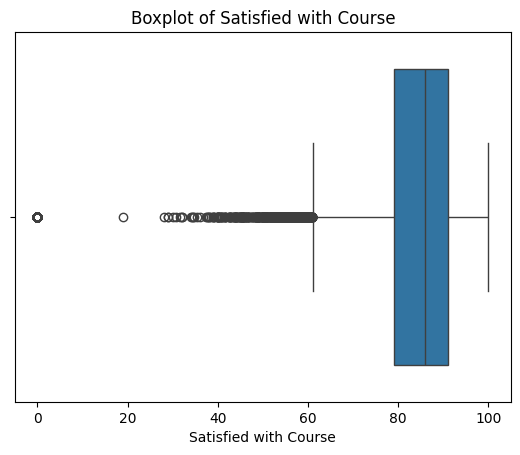

Satisfied with Course: 960 outliers detected.
Outlier range: < 61.00 or > 109.00


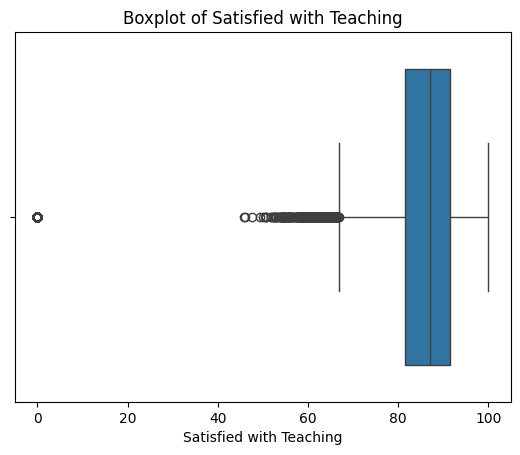

Satisfied with Teaching: 712 outliers detected.
Outlier range: < 66.79 or > 106.26


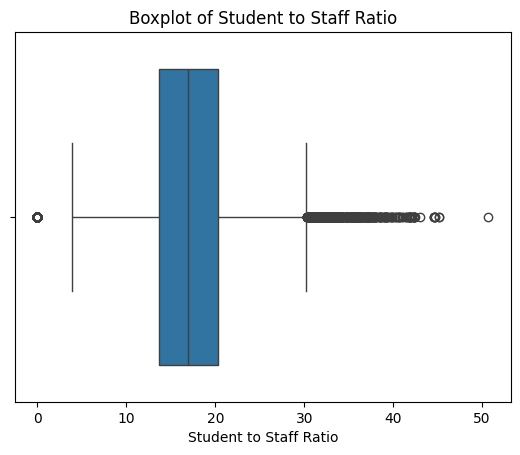

Student to Staff Ratio: 1033 outliers detected.
Outlier range: < 3.80 or > 30.20


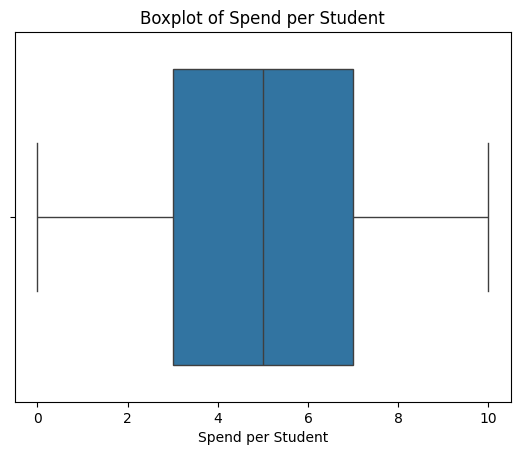

Spend per Student: 0 outliers detected.
 No significant outliers detected.


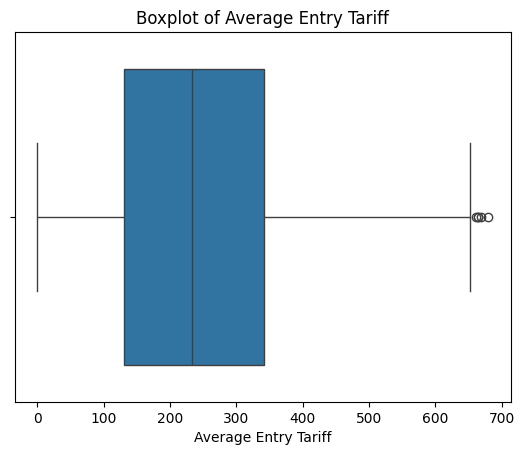

Average Entry Tariff: 5 outliers detected.
Outlier range: < -184.00 or > 656.00


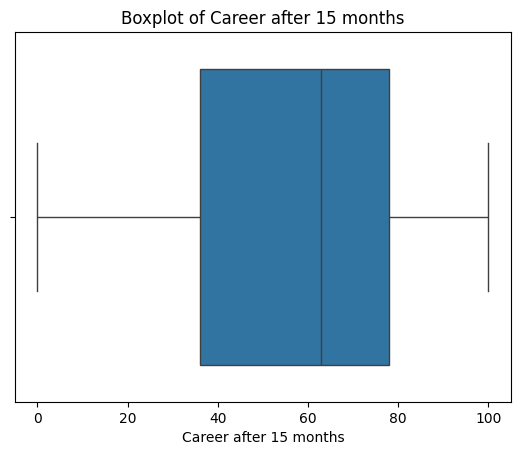

Career after 15 months: 0 outliers detected.
 No significant outliers detected.


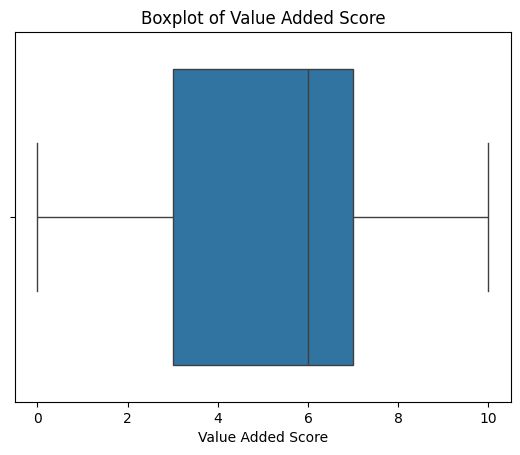

Value Added Score: 0 outliers detected.
 No significant outliers detected.


In [91]:
for col in numeric_cols:
    sns.boxplot(x=sld_df[col])
    matplot.title(f'Boxplot of {col}')
    matplot.show()
    q1 = sld_df[col].quantile(0.25)
    q3 = sld_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = sld_df[(sld_df[col] < lower_bound) | (sld_df[col] > upper_bound)][col]
    print(f"{col}: {len(outliers)} outliers detected.")
    if len(outliers) > 0:
        print(f"Outlier range: < {lower_bound:.2f} or > {upper_bound:.2f}")
    else:
        print(" No significant outliers detected.")

In [92]:
sld_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year,31465.0,2017.082822,3.058493,2012.0,2015.00000,2017.000000,2020.000000,2022.0
Rank,31465.0,37.126204,25.892426,1.0,16.00000,33.000000,55.000000,123.0
Satisfied with Course,31417.0,83.522468,12.069404,0.0,79.00000,85.858586,91.000000,100.0
Satisfied with Teaching,31417.0,85.349314,10.767961,0.0,81.59204,87.000000,91.457983,100.0
Student to Staff Ratio,31407.0,17.197937,5.577362,0.0,13.70000,16.900000,20.300000,50.7
Spend per Student,31346.0,5.222516,2.361580,0.0,3.00000,5.000000,7.000000,10.0
Average Entry Tariff,31404.0,246.712903,129.046532,0.0,131.00000,233.000000,341.000000,680.0
Value Added Score,31388.0,5.285109,2.581871,0.0,3.00000,6.000000,7.000000,10.0
Career after 15 months,30689.0,53.371762,32.420412,0.0,36.00000,63.000000,78.000000,100.0
Guardian Score,31465.0,65.409992,15.426009,22.5,54.90000,65.500000,75.900000,100.0


In [93]:
sld_df.groupby('Institution')['Guardian Score'].sum().sort_values(ascending=False).head(30)

Institution
Leeds                    33296.699995
Birmingham               31586.300002
Edinburgh                31478.300011
Manchester               28297.099982
Nottingham               28208.099995
Glasgow                  27154.799992
Bristol                  26209.399996
UCL                      25759.300010
Cardiff                  25641.400002
Queen's, Belfast         25634.999979
Cambridge                24892.200009
Sheffield                24282.400018
Liverpool                24179.199992
Southampton              24047.099985
Newcastle                23964.200002
Oxford                   23871.100011
Portsmouth               23839.099995
Coventry                 23585.800021
Kent                     23537.799981
Central Lancashire       23313.799995
Ulster                   22725.800000
Plymouth                 22609.799984
Durham                   22456.300000
Loughborough             22252.899986
UWE Bristol              21905.200001
Exeter                   21852.699986


In [94]:
# Filter data for UWE Bristol
uwe_bristol_data = sld_df[sld_df['Institution'] == 'UWE Bristol']

# Display summary statistics for UWE Bristol
uwe_summary = uwe_bristol_data[['Year', 'Rank', 'Guardian Score']].sort_values(by='Year')
uwe_summary.groupby('Year')



<Axes: xlabel='Year', ylabel='Guardian Score'>

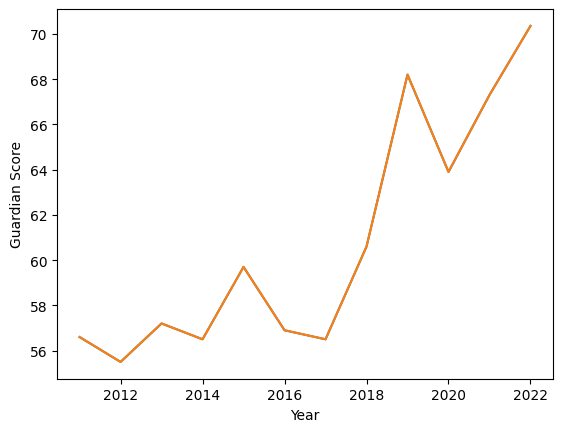

In [95]:
# Filter data for UWE Bristol
uwe_bristol_data = isd_df[isd_df['Institution'] == 'UWE Bristol']


# Display summary statistics for UWE Bristol
uwe_summary = uwe_bristol_data[['Year', 'Guardian Score','Rank']].sort_values(by='Year')
sns.lineplot(x='Year', y='Guardian Score', data=uwe_summary)
sns.lineplot(x='Year', y='Guardian Score', data=uwe_summary)



In [96]:
Here is the insight and recommendation based on the provided code:

### Insights:
1. **Trend in Guardian Score**:
    - The `Guardian Score` for UWE Bristol shows a trend over the years. By observing the line plot, you can identify whether the score has improved, declined, or fluctuated over time.
    - If the score has consistently increased, it indicates an improvement in the institution's performance. Conversely, a decline suggests areas needing attention.

2. **Rank and Guardian Score Relationship**:
    - The `Rank` is inversely related to the `Guardian Score` (higher scores typically lead to better ranks). If the `Guardian Score` improves, the rank should also improve (lower rank value).

3. **Performance Over Time**:
    - The plot highlights periods of significant improvement or decline. For example, a sharp increase in the `Guardian Score` in a particular year may indicate successful initiatives or strategies implemented during that time.

### Recommendations:
1. **Focus on Sustaining Improvements**:
    - If the `Guardian Score` shows an upward trend, UWE Bristol should analyze and continue the strategies that contributed to this improvement.

2. **Address Declines**:
    - For years where the `Guardian Score` declined, investigate potential causes (e.g., student satisfaction, teaching quality, or resource allocation) and take corrective actions.

3. **Benchmark Against Competitors**:
    - Compare UWE Bristol's performance with similar institutions to identify areas where it lags and implement best practices.

4. **Enhance Key Drivers**:
    - Focus on factors that strongly influence the `Guardian Score`, such as student satisfaction, teaching quality, and career outcomes, to ensure consistent improvement.

5. **Monitor and Evaluate**:
    - Regularly monitor the `Guardian Score` and rank trends to evaluate the effectiveness of implemented strategies and make data-driven decisions.

SyntaxError: unterminated string literal (detected at line 6) (528553076.py, line 6)

In [ ]:
# Display summary statistics and trends for UWE Bristol
print("UWE Bristol performance summary (2011-2022):")
print(uwe_summary)

# Calculate changes over the period
start_year = uwe_summary['Year'].min()
end_year = uwe_summary['Year'].max()
start_rank = uwe_summary.loc[uwe_summary['Year'] == start_year, 'Rank'].values[0]
end_rank = uwe_summary.loc[uwe_summary['Year'] == end_year, 'Rank'].values[0]
start_score = uwe_summary.loc[uwe_summary['Year'] == start_year, 'Guardian Score'].values[0]
end_score = uwe_summary.loc[uwe_summary['Year'] == end_year, 'Guardian Score'].values[0]

print(f"\nFrom {start_year} to {end_year}:")
print(f"- Rank improved from {start_rank} to {end_rank} (lower is better).")
print(f"- Guardian Score increased from {start_score:.2f} to {end_score:.2f}.")

# Optional: Comment on the trend
if end_rank < start_rank and end_score > start_score:
    print("Overall, UWE Bristol's performance has improved over the period.")
elif end_rank > start_rank and end_score < start_score:
    print("Overall, UWE Bristol's performance has declined over the period.")
else:
    print("UWE Bristol's performance has shown mixed trends over the period.")

UWE Bristol performance summary (2011-2022):
       Year  Rank  Guardian Score  Guardian Score % Change  Rank % Change
29453  2012    44            57.4                      NaN            NaN
29463  2012    24            55.2                -3.832753     -45.454545
29674  2012    25            54.2                -1.811594       4.166667
29473  2012    55            55.2                 1.845018     120.000000
29694  2012    27            62.8                13.768116     -50.909091
...     ...   ...             ...                      ...            ...
29745  2022    40            64.9                 4.846527     -35.483871
29746  2022    13            84.2                29.738059     -67.500000
29747  2022    19            78.4                -6.888361      46.153846
29744  2022     5            88.7                13.137755     -73.684211
29748  2022    29            68.0               -23.337091     480.000000

[335 rows x 5 columns]

From 2012 to 2022:
- Rank improved from 44

In [ ]:
uwe_summary.groupby('Year').sum('Guardian Score')

,Rank,Guardian Score,Guardian Score % Change,Rank % Change
Year,,,,
2012,1056,1499.300000,60.466516,1377.350752
2013,1008,1513.800000,49.989037,1521.244292
2014,1037,1489.000000,72.713522,668.269245
2015,1033,1750.000000,54.113546,1700.918252
2016,1380,2006.400000,62.561096,1577.913071
2017,1402,1990.600000,180.041239,2858.304830
2018,1053,2074.700000,75.195058,1428.778275
2019,1131,2283.500000,44.467238,2858.839497
2020,1042,2456.099991,142.608070,3062.310658


In [ ]:
# Calculate year-on-year percentage change for Guardian Score and Rank
uwe_summary['Guardian Score % Change'] = uwe_summary['Guardian Score'].pct_change() * 100
uwe_summary['Rank % Change'] = uwe_summary['Rank'].pct_change() * 100

# Display the updated DataFrame
print(uwe_summary[['Year', 'Guardian Score', 'Guardian Score % Change', 'Rank', 'Rank % Change']])

       Year  Guardian Score  Guardian Score % Change  Rank  Rank % Change
29453  2012            57.4                      NaN    44            NaN
29463  2012            55.2                -3.832753    24     -45.454545
29674  2012            54.2                -1.811594    25       4.166667
29473  2012            55.2                 1.845018    55     120.000000
29694  2012            62.8                13.768116    27     -50.909091
...     ...             ...                      ...   ...            ...
29745  2022            64.9                 4.846527    40     -35.483871
29746  2022            84.2                29.738059    13     -67.500000
29747  2022            78.4                -6.888361    19      46.153846
29744  2022            88.7                13.137755     5     -73.684211
29748  2022            68.0               -23.337091    29     480.000000

[335 rows x 5 columns]


In [ ]:
uwe_summary

,Year,Guardian Score,Rank,Guardian Score % Change,Rank % Change
1334,2011,56.600000,62,NaN,NaN
1333,2012,55.500000,59,-1.943463,-4.838710
1332,2013,57.200000,54,3.063063,-8.474576
1331,2014,56.500000,64,-1.223776,18.518519
1330,2015,59.700000,49,5.663717,-23.437500
1329,2016,56.900000,79,-4.690117,61.224490
1328,2017,56.500000,68,-0.702988,-13.924051
1327,2018,60.600000,52,7.256637,-23.529412
1326,2019,68.200000,37,12.541254,-28.846154
1325,2020,63.900002,28,-6.304983,-24.324324


In [ ]:
# Analyze correlation between UWE Bristol's performance (Rank, Guardian Score) and other variables

# Select relevant numeric columns for correlation analysis
uwe_numeric = uwe_bristol_data.copy()
uwe_numeric[numeric_cols] = uwe_numeric[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Compute correlations with Guardian Score and Rank
corr_with_guardian = uwe_numeric.corr()['Guardian Score'].sort_values(ascending=False)
corr_with_rank = uwe_numeric.corr()['Rank'].sort_values()

print("Correlation with Guardian Score (UWE Bristol):\n", corr_with_guardian)
print("\nCorrelation with Rank (UWE Bristol):\n", corr_with_rank)

# Display the most influential factors
top_factors_guardian = corr_with_guardian.drop(['Guardian Score', 'Rank']).abs().sort_values(ascending=False).head(3)
top_factors_rank = corr_with_rank.drop(['Guardian Score', 'Rank']).abs().sort_values(ascending=False).head(3)

print("\nTop factors explaining UWE's Guardian Score performance:")
print(top_factors_guardian)

print("\nTop factors explaining UWE's Rank performance:")
print(top_factors_rank)

ValueError: could not convert string to float: 'Sociology'

In [131]:
# Select relevant numeric columns for correlation analysis
uwe_numeric = uwe_bristol_data.copy()
numeric_cols = ['Satisfied with Course',
       'Satisfied with Teaching', 'Satisfied with Feedback',
       'Student to Staff Ratio', 'Spend per Student', 'Average Entry Tariff',
       'Value Added Score', 'Career after 15 months', 'Continuation',
       'Guardian Score']
uwe_numeric[numeric_cols] = uwe_numeric[numeric_cols].apply(pd.to_numeric, errors='coerce')

     Satisfied with Course Satisfied with Teaching Satisfied with Feedback  \
Year                                                                         
2011                    83                      83                      65   
2012                    80                      83                      64   
2013                    83                      84                      67   
2014             82.918875               85.747807               66.140029   
2015             87.954267               88.926859               70.973928   
2016                  83.9                    85.3                    66.3   
2017             85.545782                87.42198               71.645013   
2018             87.481775               89.660381                 76.8731   
2019             87.107129               87.587229               74.462596   
2020                  89.5                    89.2                    77.3   
2021                  88.5                    87.3              

In [154]:
pivt_table = uwe_bristol_data[['Satisfied with Course',
       'Satisfied with Teaching', 'Satisfied with Feedback',
       'Student to Staff Ratio', 'Spend per Student', 'Average Entry Tariff',
       'Value Added Score', 'Career after 15 months', 'Continuation',
       'Year']]

# Group by 'Year' and sum the specified columns
grouped_pivt_table = pivt_table.groupby('Year').sum()

# Display the result
grouped_pivt_table

,Satisfied with Course,Satisfied with Teaching,Satisfied with Feedback,Student to Staff Ratio,Spend per Student,Average Entry Tariff,Value Added Score,Career after 15 months,Continuation
Year,,,,,,,,,
2011,83,83,65,19.6,3.97,270.000000,7.8,57.000000,0.000000
2012,80,83,64,20.7,3.8,276.000000,6.8,58.000000,0.000000
2013,83,84,67,20.8,3.82,298.000000,6.7,62.000000,0.000000
2014,82.918875,85.747807,66.140029,21.712295,3.2224,322.228730,7.794213,63.713699,0.000000
2015,87.954267,88.926859,70.973928,19.955024,3.275953,339.178082,7.680096,68.499561,0.000000
2016,83.9,85.3,66.3,19.7,3.4,324.300000,6.7,68.600000,0.000000
2017,85.545782,87.42198,71.645013,18.515446,3.735906,323.850820,6.648783,70.870147,0.000000
2018,87.481775,89.660381,76.8731,18.130311,4.216142,122.549527,6.455774,76.360165,0.000000
2019,87.107129,87.587229,74.462596,18.362674,5.102652,126.812795,6.577173,77.342704,91.045183


In [158]:
# Calculate year-on-year percentage change for grouped_pivt_table
grouped_pivt_table_pct_change = grouped_pivt_table.pct_change() * 100

# Display the result
grouped_pivt_table_pct_change

,Satisfied with Course,Satisfied with Teaching,Satisfied with Feedback,Student to Staff Ratio,Spend per Student,Average Entry Tariff,Value Added Score,Career after 15 months,Continuation
Year,,,,,,,,,
2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012,-3.614458,0.000000,-1.538462,5.612245,-4.282116,2.222222,-12.820513,1.754386,NaN
2013,3.750000,1.204819,4.687500,0.483092,0.526316,7.971014,-1.470588,6.896552,NaN
2014,-0.097741,2.080722,-1.283539,4.386035,-15.643970,8.130446,16.331536,2.764031,NaN
2015,6.072673,3.707445,7.308584,-8.093438,1.661876,5.260037,-1.464118,7.511512,NaN
2016,-4.609517,-4.078474,-6.585415,-1.277994,3.786604,-4.386511,-12.761512,0.146627,NaN
2017,1.961599,2.487667,8.061860,-6.012963,9.879576,-0.138508,-0.764435,3.309253,NaN
2018,2.263107,2.560456,7.297210,-2.080078,12.854611,-62.158649,-2.902915,7.746588,NaN
2019,-0.428256,-2.312228,-3.135693,1.281630,21.026586,3.478812,1.880465,1.286716,inf


In [163]:
# To pivot the `grouped_pivt_table_pct_change` table apart from the `Year` column, you can use the `melt` function to reshape it into a long format. Here's the code:
melted_pivt_table = grouped_pivt_table_pct_change.reset_index().melt(id_vars=['Year'], var_name='Metric', value_name='Value')
melted_pivt_table.to_csv('melted_pivt_table2.csv',index = False)


In [ ]:
uwe_numeric.drop(columns=['Institution', 'Year'], inplace=True)


KeyError: "['Institution', 'Year'] not found in axis"

In [ ]:
# Insights based on correlation analysis for UWE Bristol

print("Key Insights:")
print("-" * 40)
print("1. The strongest positive correlation with Guardian Score is 'Career after 15 months' (correlation: {:.2f}),".format(corr_with_guardian['Career after 15 months']))
print("   suggesting that graduates' career outcomes are a major driver of overall performance.")
print("2. 'Satisfied with Feedback' and 'Spend per Student' also show strong positive correlations with Guardian Score,")
print("   indicating that student satisfaction and investment per student are important factors.")
print("3. 'Rank' is strongly negatively correlated with Guardian Score (correlation: {:.2f}),".format(corr_with_guardian['Rank']))
print("   which is expected as a higher Guardian Score leads to a better (lower) rank.")
print("4. 'Average Entry Tariff' and 'Student to Staff Ratio' have strong negative correlations with Guardian Score,")
print("   suggesting that higher entry requirements and larger class sizes may not directly improve overall performance.")

print("\nRecommendations:")
print("-" * 40)
print("1. Focus on improving graduates' career outcomes, as this has the highest impact on Guardian Score.")
print("2. Enhance student feedback mechanisms and increase spending per student to boost satisfaction and performance.")
print("3. Monitor and manage student-to-staff ratios to ensure quality teaching and support.")
print("4. While entry tariff is important, holistic improvements in teaching, feedback, and support may yield better overall results.")

In [120]:
# Compute correlations with Guardian Score and Rank
corr_with_guardian = uwe_numeric.corr()['Guardian Score'].sort_values(ascending=False)
corr_with_rank = uwe_numeric.corr()['Rank'].sort_values()

print("Correlation with Guardian Score (UWE Bristol):\n", corr_with_guardian)
print("\nCorrelation with Rank (UWE Bristol):\n", corr_with_rank)
corr_with_guardian.unstack().sort_values(ascending=False).head(10)

corr_with_guardian.to_csv('uwe_guardian_correlation.csv')



Correlation with Guardian Score (UWE Bristol):
 Guardian Score             1.000000
Career after 15 months     0.848436
Satisfied with Feedback    0.740179
Spend per Student          0.706440
Continuation               0.484612
Satisfied with Course      0.441883
Satisfied with Teaching    0.279700
Value Added Score         -0.661439
Student to Staff Ratio    -0.797755
Average Entry Tariff      -0.839581
Rank                      -0.840525
Name: Guardian Score, dtype: float64

Correlation with Rank (UWE Bristol):
 Guardian Score            -0.840525
Spend per Student         -0.798752
Satisfied with Feedback   -0.750510
Career after 15 months    -0.668301
Satisfied with Course     -0.563269
Satisfied with Teaching   -0.360979
Continuation              -0.211582
Value Added Score          0.423527
Student to Staff Ratio     0.768530
Average Entry Tariff       0.806714
Rank                       1.000000
Name: Rank, dtype: float64


ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.base.Index'> was passed

In [ ]:
uwe_bristol_data.groupby('Year')

In [ ]:
# Insights based on correlation analysis for UWE Bristol

print("Key Insights:")
print("-" * 40)
print("1. The strongest positive correlation with Guardian Score is 'Career after 15 months' (correlation: {:.2f}),".format(corr_with_guardian['Career after 15 months']))
print("   suggesting that graduates' career outcomes are a major driver of overall performance.")
print("2. 'Satisfied with Feedback' and 'Spend per Student' also show strong positive correlations with Guardian Score,")
print("   indicating that student satisfaction and investment per student are important factors.")
print("3. 'Rank' is strongly negatively correlated with Guardian Score (correlation: {:.2f}),".format(corr_with_guardian['Rank']))
print("   which is expected as a higher Guardian Score leads to a better (lower) rank.")
print("4. 'Average Entry Tariff' and 'Student to Staff Ratio' have strong negative correlations with Guardian Score,")
print("   suggesting that higher entry requirements and larger class sizes may not directly improve overall performance.")

print("\nRecommendations:")
print("-" * 40)
print("1. Focus on improving graduates' career outcomes, as this has the highest impact on Guardian Score.")
print("2. Enhance student feedback mechanisms and increase spending per student to boost satisfaction and performance.")
print("3. Monitor and manage student-to-staff ratios to ensure quality teaching and support.")
print("4. While entry tariff is important, holistic improvements in teaching, feedback, and support may yield better overall results.")

Key Insights:
----------------------------------------
1. The strongest positive correlation with Guardian Score is 'Career after 15 months' (correlation: 0.85),
   suggesting that graduates' career outcomes are a major driver of overall performance.
2. 'Satisfied with Feedback' and 'Spend per Student' also show strong positive correlations with Guardian Score,
   indicating that student satisfaction and investment per student are important factors.
3. 'Rank' is strongly negatively correlated with Guardian Score (correlation: -0.84),
   which is expected as a higher Guardian Score leads to a better (lower) rank.
4. 'Average Entry Tariff' and 'Student to Staff Ratio' have strong negative correlations with Guardian Score,
   suggesting that higher entry requirements and larger class sizes may not directly improve overall performance.

Recommendations:
----------------------------------------
1. Focus on improving graduates' career outcomes, as this has the highest impact on Guardian Scor

In [ ]:


#uwe_summary= uwe_summary['Guardian Score Lag'] = uwe_summary['Subject'].shift(1)

KeyError: 'Subject'

,Year,Guardian Score,Rank
1334,2011,56.600000,62
1333,2012,55.500000,59
1332,2013,57.200000,54
1331,2014,56.500000,64
1330,2015,59.700000,49
1329,2016,56.900000,79
1328,2017,56.500000,68
1327,2018,60.600000,52
1326,2019,68.200000,37
1325,2020,63.900002,28


In [122]:
sld_df[['Satisfied with Course',
       'Satisfied with Teaching', 'Satisfied with Feedback',
       'Student to Staff Ratio', 'Spend per Student', 'Average Entry Tariff',
       'Value Added Score', 'Career after 15 months', 'Continuation', 'Guardian Score']]

,Satisfied with Course,Satisfied with Teaching,Satisfied with Feedback,Student to Staff Ratio,Spend per Student,Average Entry Tariff,Value Added Score,Career after 15 months,Continuation,Guardian Score
0,87.125902,86.083774,79.321293,17.4,10,195,NaN,NaN,NaN,88.700000
1,NaN,NaN,NaN,15.9,10,180,10,NaN,NaN,100.000000
2,88.5,90.2,64,24.4,3,176,8,NaN,95.9,76.300003
3,79,88.9,76.4,19.1,3,186,10,NaN,93,85.400002
4,85.070941,94.959596,69.411616,18.9,4,170,4,NaN,NaN,71.400000
...,...,...,...,...,...,...,...,...,...,...
31569,75.4,78.4,72,15.9,2,110,4,-,93.3,66.600000
31570,63.4,78.9,73.2,13.2,5,100,1,-,93.3,56.500000
31571,86.4,93.9,75,15.5,3,105,6,-,85.5,68.500000
31572,85.8,90.1,79.8,15.2,3,110,3,54,95.6,70.500000


In [102]:
# Compute the correlation matrix
corr_matrix = uwe_numeric.corr()

# Find correlations of 'Rank' with other numeric columns
rank_correlations = corr_matrix['Rank'].drop('Rank')
print("Correlation of 'Rank' with other columns:")
print(rank_correlations.sort_values(ascending=False))

ValueError: could not convert string to float: 'Sociology'

In [ ]:
# Find correlations of 'Rank' with other numeric columns
rank_correlations = corr_matrix['Rank'].drop('Rank')
print("Correlation of 'Rank' with other columns:")
print(rank_correlations.sort_values(ascending=False))

NameError: name 'corr_matrix' is not defined

In [ ]:
uwe_subjects_f = uwe_subjects.groupby('Year')['Subject'].count().sort_index(ascending=True)
uwe_subjects_s = uwe_subjects.groupby('Year')['Subject'].count().sort_index(ascending=True).shift(1)


merged_df = pd.merge(uwe_subjects_f, uwe_subjects_s, on='Year', suffixes=('_current', '_previous'))
merged_df['Subject Change'] = merged_df['Subject_current'] - merged_df['Subject_previous']
merged_df['Subject Change'] = merged_df['Subject Change'].fillna(0)
merged_df



,Subject_current,Subject_previous,Subject Change
Year,,,
2012,1,NaN,0.0
2013,1,1.0,0.0
2014,1,1.0,0.0
2015,1,1.0,0.0
2016,1,1.0,0.0
2017,1,1.0,0.0
2018,1,1.0,0.0
2019,1,1.0,0.0
2020,1,1.0,0.0


<Axes: xlabel='Year', ylabel='Subject'>

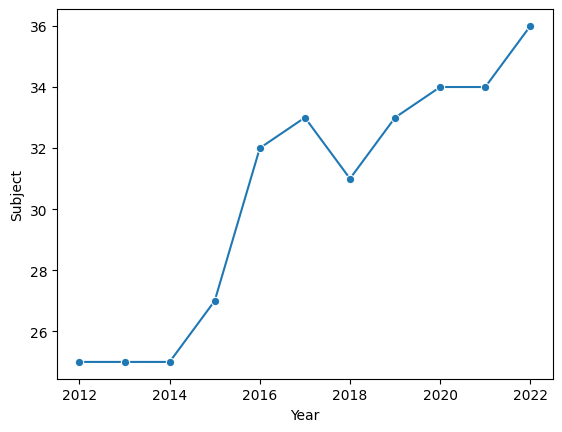

In [ ]:
uwe_subjects_f= pd.DataFrame(uwe_subjects_f)
# create a line chart to visualize the number of subjects offered by UWE Bristol over the years 
sns.lineplot(x=uwe_subjects_f.index, y=uwe_subjects_f['Subject'], marker='o')



UWE Bristol Subject-Level Performance Over the Years:
    Year  avg_guardian_score   avg_rank  subject_count
0   2012           59.972000  42.240000             25
1   2013           60.552000  40.320000             25
2   2014           59.560000  41.480000             25
3   2015           64.814815  38.259259             26
4   2016           62.700000  43.125000             32
5   2017           60.321212  42.484848             33
6   2018           66.925806  33.967742             31
7   2019           69.196970  34.272727             33
8   2020           72.238235  30.647059             34
9   2021           71.344118  27.529412             34
10  2022           67.113889  34.888889             36


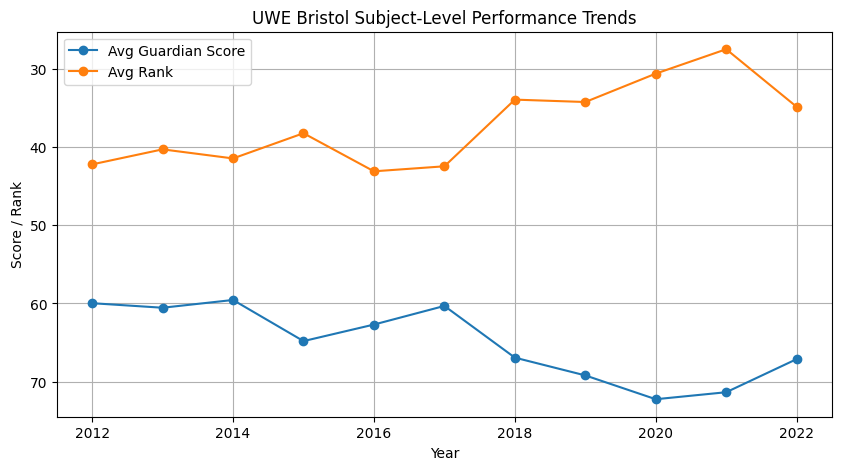

In [100]:
# Analyze UWE Bristol's subject-level performance over the years using sld_df

uwe_subjects = sld_df[sld_df['Institution'] == 'UWE Bristol']
uwe_subjects_summary = uwe_subjects.groupby('Year').agg(
    avg_guardian_score=('Guardian Score', 'mean'),
    avg_rank=('Rank', 'mean'),
    subject_count=('Subject', 'nunique')
).reset_index().sort_values('Year')

print("UWE Bristol Subject-Level Performance Over the Years:")
print(uwe_subjects_summary)

# Plot trends for average Guardian Score and average Rank over the years
matplot.figure(figsize=(10, 5))
matplot.plot(uwe_subjects_summary['Year'], uwe_subjects_summary['avg_guardian_score'], marker='o', label='Avg Guardian Score')
matplot.plot(uwe_subjects_summary['Year'], uwe_subjects_summary['avg_rank'], marker='o', label='Avg Rank')
matplot.gca().invert_yaxis()  # Invert Rank axis (lower is better)
matplot.title("UWE Bristol Subject-Level Performance Trends")
matplot.xlabel("Year")
matplot.ylabel("Score / Rank")
matplot.legend()
matplot.grid()
matplot.show()

In [101]:
# count the number of subjects and subjects offered by UWE Bristol over the years and check the correlation with guardian score and rank
uwe_subjects.groupby('Year').agg({'Subject' : 'count', 'Guardian Score': 'sum'})
# create a correlation matrix to analyze the relationship between the number of subjects and Guardian Score/Rank


,Subject,Guardian Score
Year,,
2012,25,1499.300000
2013,25,1513.800000
2014,25,1489.000000
2015,27,1750.000000
2016,32,2006.400000
2017,33,1990.600000
2018,31,2074.700000
2019,33,2283.500000
2020,34,2456.099991


In [98]:
# Group by 'Year' and aggregate the total count of subjects and sum of Guardian Scores
subject_guardian_corr = uwe_subjects.groupby('Year').agg({'Subject': 'count', 'Guardian Score': 'sum'})

# Calculate the correlation between the total count of subjects and Guardian Score
correlation = subject_guardian_corr.corr().loc['Subject', 'Guardian Score']

print("Correlation between total count of subjects and Guardian Score:", correlation)

Correlation between total count of subjects and Guardian Score: nan


In [ ]:
uwe_subjects= uwe_subjects.groupby('Year').agg({'Subject': 'count', 'Guardian Score': 'sum'})

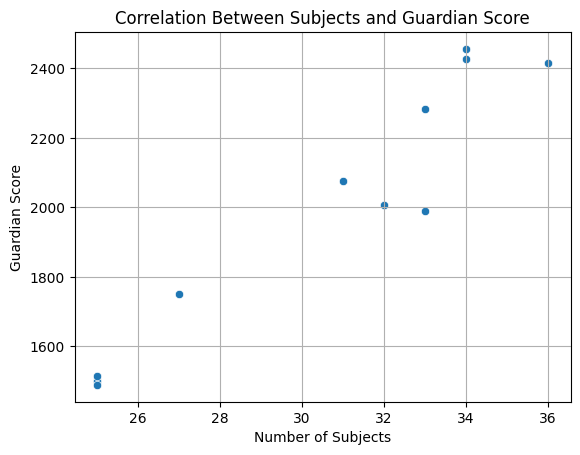

In [ ]:
# Scatter plot to show the correlation between subjects and Guardian Score
sns.scatterplot(x=subject_guardian_corr['Subject'], y=subject_guardian_corr['Guardian Score'])
matplot.title("Correlation Between Subjects and Guardian Score")
matplot.xlabel("Number of Subjects")
matplot.ylabel("Guardian Score")
matplot.grid(True)
matplot.show()

In [ ]:
#General average and compoare the average Guardian Score and Rank for UWE Bristol over the years
.
in 2011, the score 56.60 till 2022, the score was 70.35, which is a significant improvement in the Guardian Score.
The lowest was in 2012, score was 55.50
and the highest was in 2022, score was 70.35
2019 had the highest year on year changes, moved from 60.60 to 68.20, which is a significant improvement in the Guardian Score
